<a href="https://colab.research.google.com/github/MorganDiaz2513892022/MorganDiaz-Parcial4/blob/main/notebook/Clusterizacion_MorganDiazParcial4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importacion de las librerias
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Escalado y clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Métricas
from sklearn.metrics import silhouette_score

In [2]:
#carga del dataset
url = "https://raw.githubusercontent.com/MorganDiaz2513892022/MorganDiaz-Parcial4/refs/heads/main/data/clave_A_agrupacion.csv"

df = pd.read_csv(url)

print(df.head())

  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     A-R0009    18       447            0.55           21.04          5.46   
1     A-R0023    22       624            3.82           33.36          7.31   
2     A-R0099    34      1091            8.12          105.43          7.51   
3     A-R0159    46      1365           10.62          158.81          7.74   
4     A-R0221    52       570            3.82           32.46          4.63   

   reclamos  antiguedad_meses  
0         2                 7  
1         2                 1  
2         1                21  
3        12                43  
4         5                15  


In [3]:
#exploracion inicial de datos
print("Dimensiones:")
print(df.shape)

print("\nInformación general:")
print(df.info())

print("\nValores nulos:")
print(df.isnull().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

print("\nEstadísticas descriptivas:")
print(df.describe())

Dimensiones:
(230, 8)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       230 non-null    object 
 1   edad              230 non-null    int64  
 2   ingresos          230 non-null    int64  
 3   frecuencia_uso    230 non-null    float64
 4   gasto_promedio    230 non-null    float64
 5   satisfaccion      229 non-null    float64
 6   reclamos          230 non-null    int64  
 7   antiguedad_meses  230 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 14.5+ KB
None

Valores nulos:
registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        1
reclamos            0
antiguedad_meses    0
dtype: int64

Duplicados:
0

Estadísticas descriptivas:
             edad     ingresos  frecuencia_uso  gasto_promedio  sa

In [8]:
#seleccion de clustering
#únicamente columnas numéricas
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns

print("Variables numéricas:")
print(variables_numericas)

Variables numéricas:
Index(['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion',
       'reclamos', 'antiguedad_meses'],
      dtype='object')


In [9]:
#dataset para clustering
X = df[variables_numericas]

print(X.head())

   edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  reclamos  \
0    18       447            0.55           21.04          5.46         2   
1    22       624            3.82           33.36          7.31         2   
2    34      1091            8.12          105.43          7.51         1   
3    46      1365           10.62          158.81          7.74        12   
4    52       570            3.82           32.46          4.63         5   

   antiguedad_meses  
0                 7  
1                 1  
2                21  
3                43  
4                15  


Justificacion de las variables:
seleccione las variables numericas porque KMeans trabaja utilizando distancias entre observaciones y estas variables del comportamiento de los clientes permiten identificar las similitudes entre ellas como lo son gastos, encuestas de satisfaccion, los gastos que mas hacen etc.. son acciones que solo el usuario hace

In [10]:
# Verificar valores nulos
print(X.isnull().sum())

edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        1
reclamos            0
antiguedad_meses    0
dtype: int64


In [13]:
#eliminar registros con valores nulos
X=X.dropna()

In [15]:
#Escalar datos
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


Metodo del codo
El método del codo permite encontrar un número adecuado de clusters observando la reducción de la inercia.

El punto donde la disminución comienza a ser menos pronunciada suele indicar el número óptimo de grupos.

In [16]:
#aplicacion del metodo del codo
inercias = []

rangos = range(1, 11)

for k in rangos:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inercias.append(modelo.inertia_)

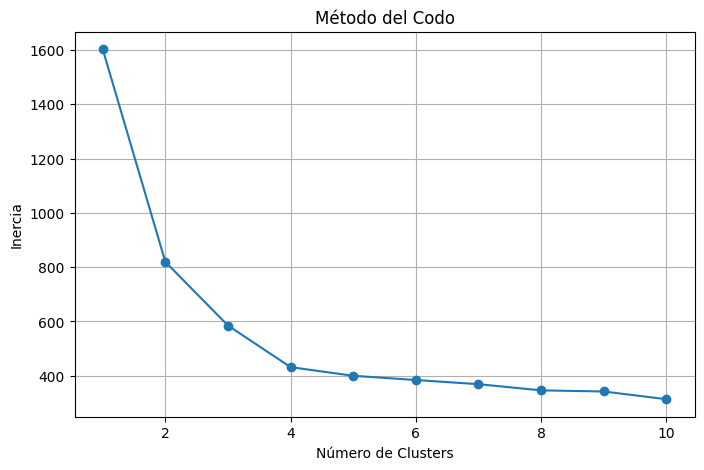

In [17]:
plt.figure(figsize=(8,5))

plt.plot(rangos, inercias, marker='o')

plt.title("Método del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")

plt.grid(True)
plt.show()

In [18]:
# Aplicar K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [19]:
# Mantener únicamente filas válidas
df = df.loc[X.index]

# Agregar columna cluster
df["cluster"] = clusters

print(df.head())

  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     A-R0009    18       447            0.55           21.04          5.46   
1     A-R0023    22       624            3.82           33.36          7.31   
2     A-R0099    34      1091            8.12          105.43          7.51   
3     A-R0159    46      1365           10.62          158.81          7.74   
4     A-R0221    52       570            3.82           32.46          4.63   

   reclamos  antiguedad_meses  cluster  
0         2                 7        1  
1         2                 1        1  
2         1                21        0  
3        12                43        2  
4         5                15        1  


In [20]:
#ver cantidad de registros por cluster
print(df["cluster"].value_counts())

cluster
1    109
0     65
2     55
Name: count, dtype: int64


In [24]:
#Obtener centroides en escala original
centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

print(centroides)

        edad     ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0  31.615385   941.815385        6.524308       78.947692      8.258462   
1  29.275229   658.990826        3.081743       43.987982      5.298073   
2  45.563636  1489.818182        9.120727      134.649818      8.502000   

   reclamos  antiguedad_meses  
0  1.184615         18.153846  
1  4.027523          8.614679  
2  0.909091         35.963636  


In [25]:
#Calcular silhouette score
#El silhouette score mide qué tan bien separados están los clusters.
silhouette = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.36965759726096586


Index(['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion',
       'reclamos', 'antiguedad_meses'],
      dtype='object')


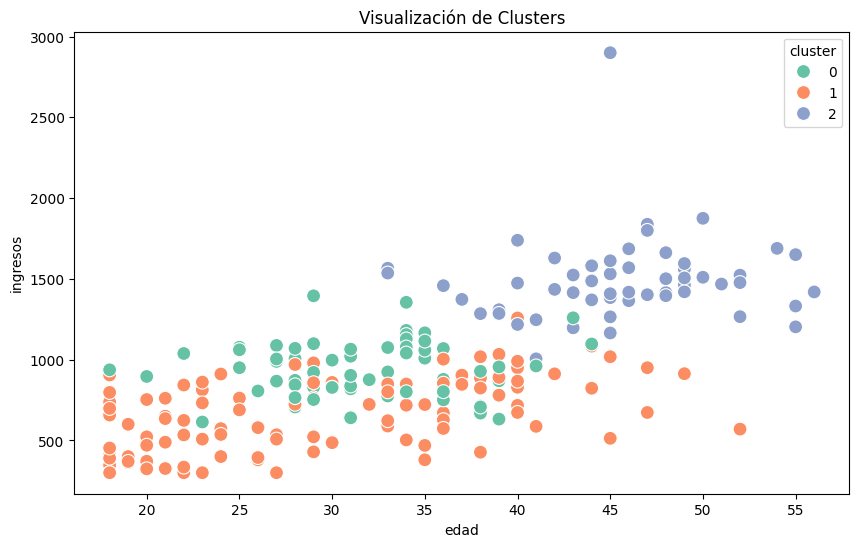

In [27]:
#viualizacion de clusters
print(X.columns)
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x=X.columns[0],
    y=X.columns[1],
    hue="cluster",
    palette="Set2",
    s=100
)

plt.title("Visualización de Clusters")

plt.show()

In [30]:
# Promedio de variables por cluster
analisis_clusters = df.groupby("cluster")[variables_numericas].mean()

print(analisis_clusters)

              edad     ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
cluster                                                                         
0        31.615385   941.815385        6.524308       78.947692      8.258462   
1        29.275229   658.990826        3.081743       43.987982      5.298073   
2        45.563636  1489.818182        9.120727      134.649818      8.502000   

         reclamos  antiguedad_meses  
cluster                              
0        1.184615         18.153846  
1        4.027523          8.614679  
2        0.909091         35.963636  
